## imports

In [24]:
#------------------------------------------------------------#
import numpy as np
from matplotlib import pyplot as plt
from numba import njit
import pickle
#------------------------------------------------------------#
from utils import colormaps as maps
from utils import load_data as ld
from utils import plot as pl
#------------------------------------------------------------#
from utils_izhi import topology as tp
from utils_izhi import izhikevic as iz
#------------------------------------------------------------#
# snn
#from snn import spikeDataProcessor as SDP
from snn import channels as ut
#------------------------------------------------------------#
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
#------------------------------------------------------------#
from utils import interventional as IC
#from utils import load_EC as lec
#from utils import correlations as cc
#from utils import distance as di
#------------------------------------------------------------#


In [25]:
#=================================================================================================#
# For Avenir font. To use it, you have to download the font-style files below.
# Comment the lines referred to fontManager if you don't need to set the font.
from matplotlib import font_manager, rcParams
font_file   = "/home/tentori/.local/avenir_ff/AvenirLTStd-Roman.otf"
font_file_b = "/home/tentori/.local/avenir_ff/AvenirLTStd-Black.otf"
font_file_c = "/home/tentori/.local/avenir_ff/AvenirLTStd-Book.otf"
font_manager.fontManager.addfont(font_file)
font_manager.fontManager.addfont(font_file_b)
font_manager.fontManager.addfont(font_file_c)
#------------------------------------------------------------#
rcParams['font.family']  = "Avenir LT Std"
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype']  = 42
#------------------------------------------------------------#
DIM = 25
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM,'ytick.labelsize': DIM})
#=================================================================================================#
# Colors
colorz    = ['#255D93','#5FA6D6','#B02106','#F24D33','#2C2C2C','#787878']
coldhot_cmap   = maps.create_cmaphot()
coldhot_cmap_r = maps.create_cmaphot_r()
#------------------------------------------------------------#
show_plot   = True
#------------------------------------------------------------#
from cmap import Colormap
def Cmap(cmap):
    return Colormap(cmap).to_mpl()
#------------------------------------------------------------#
def truncate_cmap(cmap, minval=0.0, maxval=0.8, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )
#------------------------------------------------------------#
def discrete_cmap(cmap_name='turbo', num_colors=25, minval=0., maxval=1):
    from matplotlib.colors import ListedColormap
    base = truncate_cmap(plt.get_cmap(cmap_name), minval=minval, maxval=maxval)
    return ListedColormap(base(np.linspace(0, 1, num_colors)))
#=================================================================================================#
# to create folder
def Set_Dir_Plots(path):
    import os
    if not os.path.exists(path):
        os.mkdir(path)
#=================================================================================================#

# Paths

In [26]:
#=================================================================================================#
# PARSER

modules      = '1'
dist_rule    = 'EDR'
nNeurons     = 1000
regime       = 'RS-IB'
local_II     = False
deltat       = 1
network_load = True

#=================================================================================================#
# folder

if local_II==True:
    folder       = f'network{nNeurons}_{modules}mod_{dist_rule}_II/'
else:
    folder       = f'network{nNeurons}_{modules}mod_{dist_rule}_noII/'

In [27]:
#=================================================================================================#
# data generation paths

path_results = './Data_SNNmodel/'
path_out     = path_results+'Generated_network/'+folder
path_data    = path_out+'Data/'
path_params  = path_data+'Parameters/'
path_imgs    = path_data+'Plots/'

#------------------------------------------------------------#
# create folders

Set_Dir_Plots(path_results)
Set_Dir_Plots(path_results+'Generated_network/')
Set_Dir_Plots(path_out)
Set_Dir_Plots(path_data)
Set_Dir_Plots(path_params)
Set_Dir_Plots(path_imgs)

#--------------------------------------------------------#
# empirical topology

main_path    = '/home/tentori/experimental_works/causality/Original_data/Causality/'
sim_folder   = 'Culture1REC1/'
deltat = 1
#=================================================================================================#

# 1. Network

## 1.1 Neurons map

In [28]:
if modules == '2':
    #=================================================================================================#
    # EMPIRICAL BASED MAP (2 modules)
    #------------------------------------------------------------#
    # loading empirical map features
    _, channel, _, pos, cluster, _, _, rate = ld.load_original_data(main_path, sim_folder, file='Cult.mat')
    channel = channel - 1
    cluster = tp._reorder_clusters_by_x(pos, cluster)
    # subsample channels with max rate for each group/cluster of channels
    sub_idx = tp._subsample_indices(channel, cluster, rate)
    #------------------------------------------------------------#    
    samples_orig  = pos[sub_idx,:]/1000
    samples_added = tp.add_nearby_points(samples_orig, n_new=nNeurons-samples_orig.shape[0], scale=0.05)
    samples       = np.vstack([samples_orig,samples_added])
    samples[0,0]  = 2.60;  samples[0,1]  = 0.2
    samples[1,0]  = 2.49;  samples[1,1]  = 0.15
    samples[2,0]  = 2.42;  samples[2,1]  = 0.10
    samples[2,0]  = 2.35;  samples[2,1]  = 0.05
    samples[2,0]  = 2.30;  samples[2,1]  = 0.08
    samples[3,0]  = 2.25;  samples[3,1]  = 0.15
    L       = np.argsort(samples[:,0])
    samples = samples[L,:] # sort by x-axis
    del channel, pos, cluster, sub_idx, samples_orig, samples_added, L
    
elif modules == '1':
    #=================================================================================================#
    # GENERATED MAP uniform random map
    # generate random 2D map uniformly distributed, with Poisson disk sampling
    samples, r_min_used = tp.poisson_disk_until_n(x_min=0.0, x_max=3.8/4*3, y_min=0.0, y_max=2.1/4*3, n_points=nNeurons)
    print(f"Generated {len(samples)} points, with r_min = {r_min_used:.4f}")
    L       = np.argsort(samples[:,0])  # sort by x-axis
    samples = samples[L,:]
    del r_min_used, L
    

Generated 1000 points, with r_min = 0.0513


## 1.2 Network parameters

In [29]:
def set_delays(distance_mat, weights_mat, delay_max=20, deltat=1, min_delay_steps=1,  jitter_exc_steps=1, topoType='out', seed=None):
    
    rng = np.random.default_rng(seed)

    # Masks
    no_conn = (weights_mat == 0)
    has_conn = ~no_conn
    is_inhib_edge = (weights_mat < 0)
    is_excit_edge = (weights_mat > 0)
    
    delay_max = delay_max*deltat
    
    if topoType == 'random':
        del_mat = rng.integers(1*deltat, high=delay_max+1, size=distance_mat.shape, dtype=int)
    else:
        del_mat = np.copy(distance_mat)/np.max(distance_mat.flatten())
        del_mat = (del_mat*delay_max).astype(int)+1
    del_mat[weights_mat<0]  = int(min_delay_steps/deltat)

    # Optional excitatory jitter (0..jitter_exc_steps)
    if jitter_exc_steps > 0:
        jitter = rng.integers(0, jitter_exc_steps + 1, size=del_mat.shape, dtype=int)
        jitter[~is_excit_edge] = 0
        del_mat += jitter
        # Re-enforce minimum and clip by delay_max if provided
        del_mat[has_conn] = np.maximum(del_mat[has_conn], int(min_delay_steps/deltat))
        if delay_max is not None:
            del_mat[has_conn] = np.minimum(del_mat[has_conn], delay_max)

    del_mat[weights_mat==0] = 0
    
    return del_mat


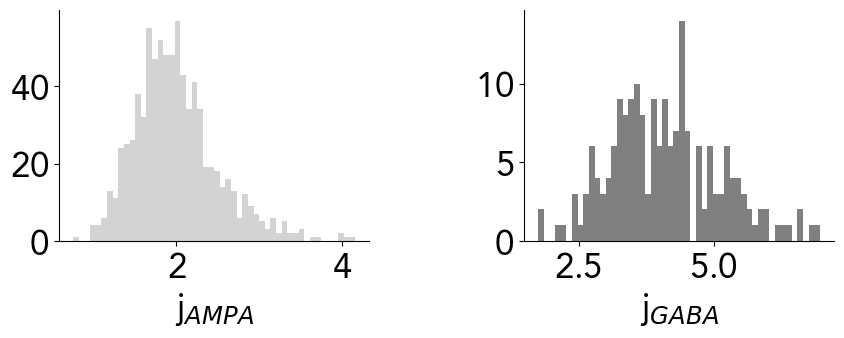

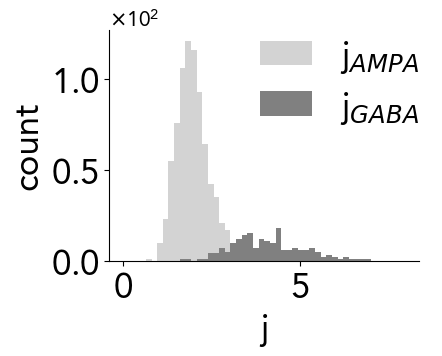

In [30]:
if network_load==False:

    # ------------------------------------------------------------------------------------------------------------#
    # network parameters
    net = { }
    
    net['neurons'] = len(samples)                # number of neurons
    net['pos']     = samples                     # neuron positions
    net['channel'] = np.arange(len(samples))     # neuron index
    net['modules'] = np.zeros(net['neurons'])    # module IDs
    if modules=='2':
        net['modules'][net['pos'][:,0]>2.4]=1
        
    # neuron types and connectivity parameters
    net['rho']     = 0.8                         # fraction of excitatoy/inhibitory neurons
    net['ntypes']  = np.random.rand(net['neurons']) < net['rho']  # boolean array
    exc_idx        = np.where(net['ntypes'])[0]
    inh_idx        = np.where(~net['ntypes'])[0]
    
    # set parameters
    # pay attention: these random numbers decide the izhikevic parameters of each neuron. 
    #                It has to be the same for all simulations based on the same exact topology
    #net['nrands']   = np.random.rand(net['neurons'])      # random numbers for model parameters    #np.random.seed(None)
    net['nrands'] = np.zeros(nNeurons)
    # excitatory nrands : random numbers betw 0 and 1
    net['nrands'][exc_idx] = np.random.rand(exc_idx.size)
    # inhibitory nrands : FS=0, LTS=1 randomly chosen among inh_idxs
    p_FS   = 0.75    # % FS
    p_LTS  = 1-p_FS  # % LTS
    n_inh  = inh_idx.size
    n_FS   = int(np.round(p_FS * n_inh))
    labels = np.array([0]*n_FS + [1]*(n_inh-n_FS))
    np.random.shuffle(labels)
    net['nrands'][inh_idx] = labels
    
    #----------------------------------------------------------------------------------------------------------------#
    # adjacency
    net['w_mean_exc']  = 6.0; net['w_mean_inh']  = 5.0
    '''
    W, dist_mat = tp.EDR_Connections_clean_old(samples, net, p0_E=0.75, L_E=0.14, c_E=0.0, r_IE=0.18, p_IE=0.75, 
                                           r_II=0.18,  p_II=0.75, local_II=local_II, LTS_th=0.7,
                                           W_decay_exc=1.5, W_decay_inh=1., cv_exc=0.35, cv_inh=0.10, seed=None)
    '''

    W, dist_mat = tp.EDR_Connections_clean(samples, net, p0_E=0.65, L_E=0.155, c_E=0.0, r_IE=0.18, p_FS2E=0.75, p_LTS2E=0.75, 
                                          r_II=0.18, p_FS2FS=0.75, p_LTS2LTS=0.35, local_II=local_II, LTS_th=0.75,  
                                          W_decay_exc=1.5, W_decay_inh=1.0, cv_exc=0.35, cv_inh=0.2, seed=None) 
    
    net['weights']       = W
    net['dist_matrix']   = dist_mat
    #----------------------------------------------------------------------------------------------------------------#
    # delays
    net['max_delay_exc'] = 40         # (ms)  delays for excitatory connections go from 1 to 'max_delay_exc'
    net['max_delay_inh'] = 1                    # (ms)  delays for inhibitory connections is set only to 'max_delay_inh'
    speed = 0.3
    '''
    net['delays']        = tp.set_delays(dist_mat, W, deltat=deltat, topoType='distance', delay_max=20, mean_speed=speed, cv_speed=speed,
                                    separate_inhibitory_speed=True, inh_speed=speed, min_delay_steps=int(net['max_delay_inh']/deltat),
                                    force_inhibitory_min_delay=True, jitter_exc_steps=1, seed=None)
    '''

    net['delays']        = set_delays(dist_mat, W, delay_max=net['max_delay_exc'], deltat=deltat, min_delay_steps=net['max_delay_inh'],  
                                       jitter_exc_steps=1, topoType='out', seed=None)
    
    #----------------------------------------------------------------------------------------------------------------#
    # gain
    net['j_AMPA']   = np.zeros(nNeurons)
    net['j_GABA']   = np.zeros(nNeurons)
    # gains heterogeneity
    rng = np.random.default_rng()
    E = net['ntypes'].astype(bool); I = ~E
    def lnorm(mean, cv, n):
        s = np.sqrt(np.log(1+cv*cv)); m = np.log(mean) - 0.5*s*s
        return rng.lognormal(m, s, n)
    net['j_AMPA'][E] = lnorm(2., 0.25, E.sum())
    net['j_GABA'][I] = lnorm(4., 0.25, I.sum())
    fig,ax=plt.subplots(1,2,figsize=(10,3)); 
    h=ax[0].hist(net['j_AMPA'][E],50, color='lightgrey'); 
    ax[0].set_xlabel('j$_{AMPA}$');  
    h=ax[1].hist(net['j_GABA'][I],50, color='grey'); 
    ax[1].set_xlabel('j$_{GABA}$')
    for a in ax: pl.set_format(ax=a, DIM= DIM, pwr_x_max=2, pwr_y_max=2)
    fig.subplots_adjust(wspace=0.5)
    plt.savefig(path_imgs + 'j_AMPA_GABA.png', bbox_inches='tight')
    
    fig,ax=plt.subplots(figsize=(4,3)); 
    ax.hist(net['j_AMPA'][E], 50, [0,8], color='lightgrey', label='j$_{AMPA}$') 
    ax.hist(net['j_GABA'][I], 50, [0,8], color='grey', label='j$_{GABA}$')
    ax.set_ylabel('count')
    ax.set_xlabel('j'); 
    pl.set_format(ax=ax, DIM= DIM, pwr_x_max=2, pwr_y_max=2)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), labelspacing=0.4, 
              handletextpad=0.8, handlelength = 1.5, frameon=False)
    plt.savefig(path_imgs + 'j_AMPA_GABA_2.png', bbox_inches='tight')
    
    net['deltat'] = 1
    
    #================================================================================================================#
    #                                                DATA SAVE
    # save the network
    with open(path_data+'net.pkl', 'wb') as file:
        pickle.dump(net, file)
    #----------------------------------------------------------------------------------------------------------------#
    # save additional features (optional)
    np.savetxt(path_data+'net_n_positions.txt',net['pos'])
    np.savetxt(path_data+'net_n_channel.txt',net['channel'])
    #================================================================================================================#

else:
    with open(path_data+'net.pkl', 'rb') as file:
        net = pickle.load(file)
    deltat   = 1#net['deltat']
    samples  = net['pos']
    W        = net['weights']
    dist_mat = net['dist_matrix']

## 1.3 select stimulation channels

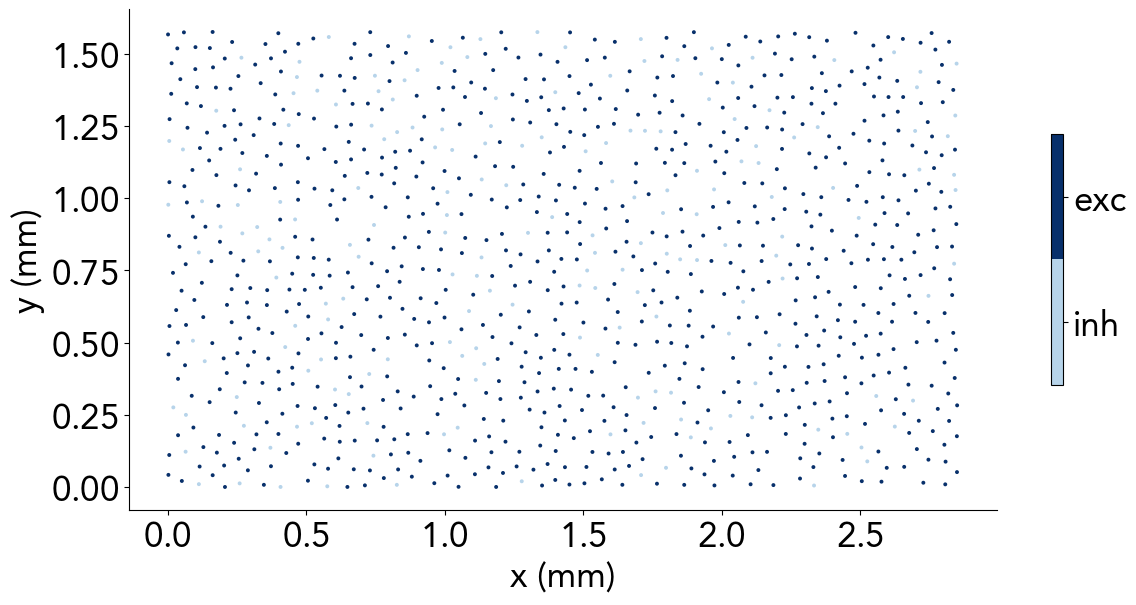

In [31]:
#---------------------------------------------------------------------------------------------------#
# PLOT: neurons map

cmap2 = discrete_cmap('Blues', 2, minval=0.3, maxval=1)

# FULL MAP OF CHANNELS 
x = samples[:, 0]
y = samples[:, 1]

fig, ax = plt.subplots(figsize=(14, 6.5))
scatter = ax.scatter(x, y, s=8, marker='o', edgecolor='white', linewidths=0.01, c=net['ntypes'], cmap=cmap2, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM);    ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter,ax=ax,shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
plt.savefig(path_imgs + 'connectivity_neurons_map.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------#


19


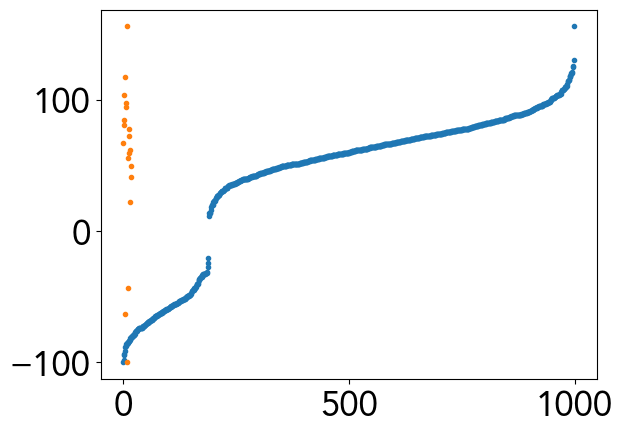

In [32]:
#---------------------------------------------------------------------------------------------------------------#
# select stimulation channels
outStr = np.sum(W,axis=-1)
L      = np.argsort(outStr)
ix=np.where( ( ( (samples[:,0]>2) & (samples[:,0]<2.7) ) & ( (samples[:,1]>0) & (samples[:,1]<0.3) ) ) & (net['ntypes']==True) )[0]
ix2=np.where( ( ( (samples[:,0]>0.3) & (samples[:,0]<2.) ) & ( (samples[:,1]>0) & (samples[:,1]<0.5) ) ) & (net['ntypes']==True) )[0]

stim_chans = np.unique( np.concatenate([ [L[i] for i in range(0,int(nNeurons*0.2),80)], [L[i] for i in range(int(nNeurons*0.2),nNeurons-61,80)], [L[i] for i in range(nNeurons-61,nNeurons,25)], [L[-1]], [ix[0]], [ix2[0]] ]) ) #np.concatenate([L[-5:-1], [L[int(nNeurons*i/10)] for i in range(3,10)], [ix[0]], ])
#stim_chans = np.unique( np.concatenate([ [L[-1]], [i for i in range(10,nNeurons,50)], [ix[0]], [ix2[0]] ]) ) #np.concatenate([L[-5:-1], [L[int(nNeurons*i/10)] for i in range(3,10)], [ix[0]], ])

indices       = np.copy(stim_chans)
def_units     = np.arange(len(stim_chans))
def_chans     = np.copy(stim_chans)

print(len(indices))
np.save(path_data + 'def_units.npy', def_units)
np.save(path_data + 'def_chans.npy', def_chans)

plt.plot(outStr[L],'.')
plt.plot(outStr[stim_chans],'.')

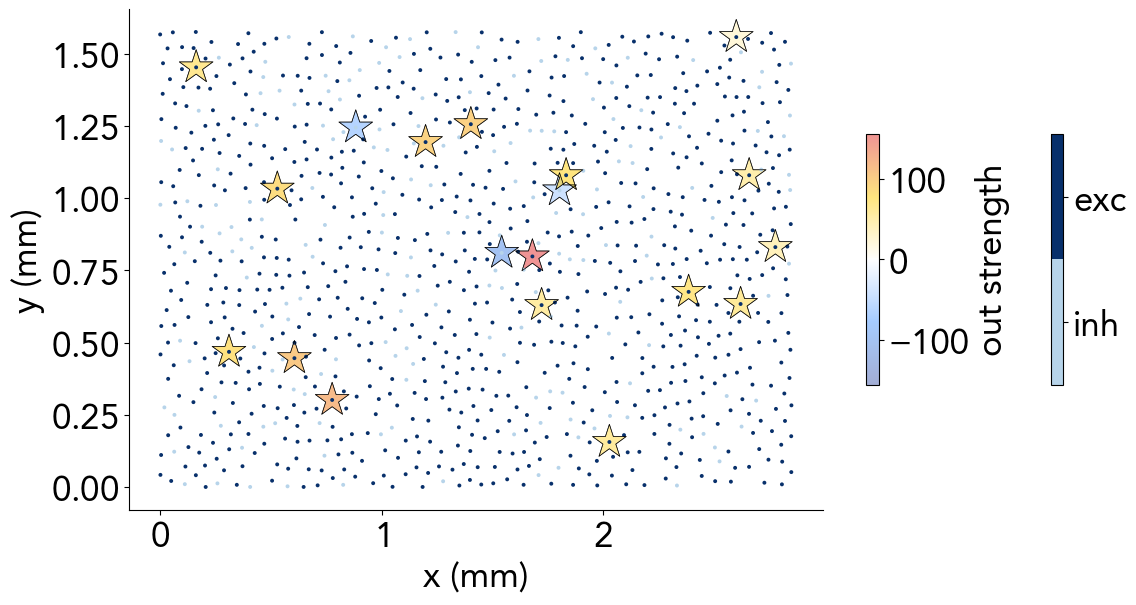

In [33]:
cmap2 = discrete_cmap('Blues', 2, minval=0.3, maxval=1)

# FULL MAP OF CHANNELS 
x = samples[:, 0]
y = samples[:, 1]

fig, ax = plt.subplots(figsize=(14, 6.5))
scatter = ax.scatter(x, y, s=8, marker='o', edgecolor='white', linewidths=0.01, c=net['ntypes'], cmap=cmap2, zorder=1)

ax.scatter(x[stim_chans], y[stim_chans], s=650, marker='*', edgecolor='k', linewidths=0.5, c='none', zorder=1)
scatter2=ax.scatter(x[stim_chans], y[stim_chans], s=650, marker='*', edgecolor='k', linewidths=0.5, 
                    c=outStr[stim_chans], cmap=coldhot_cmap, vmin=-np.max(np.abs(outStr)), vmax=np.max(np.abs(outStr)),
                    alpha=0.5, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM);    ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter,ax=ax,shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])

cbar = fig.colorbar(scatter2,ax=ax,shrink=0.5)
cbar.set_label('out strength')

plt.savefig(path_imgs + 'map_stim.png', bbox_inches='tight')


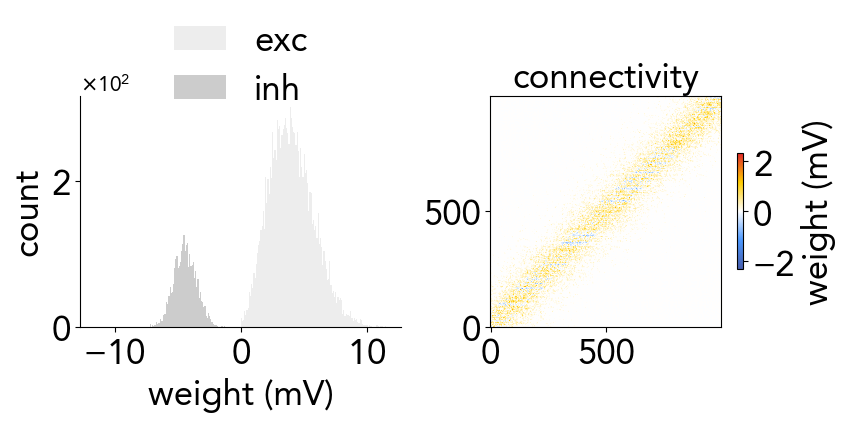

In [34]:
#---------------------------------------------------------------------------------------------------------------#
# PLOT: CONNECTIVITY

fig,axs=plt.subplots(1,2,figsize=(9.1,3))
#===  Weights histogram   ===#
W_max = np.max(np.abs(W).flatten())
ax=axs[0]
ax.hist(W[W>0], len(W)//4, [-W_max,W_max], color='lightgrey', alpha=0.4, density=False, label='exc')
ax.hist(W[W<0], len(W)//4, [-W_max,W_max], color='grey', density=False, alpha=0.4,  label='inh')
ax.set_xlabel('weight (mV)')
ax.set_ylabel('count')
ax.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.45), labelspacing=0.4, handletextpad=0.8, handlelength = 1.5, frameon=False) 
pl.set_format(ax=ax, DIM = DIM, pwr_x_max=2, pwr_y_max=2, pwr_y_min=-2)
#===   Adjacency matrix   ===#
ax=axs[1]
im = ax.imshow(W,cmap=coldhot_cmap, vmin=-np.max(np.abs(W.flatten()))/5, vmax=np.max(np.abs(W.flatten()))/5 )
ax.invert_yaxis()
ax.set_title('connectivity')
cbar = fig.colorbar(im, ax=ax, shrink=0.5, label='weight (mV)')
plt.savefig(path_imgs + 'connectivity_weights.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------------------#


links fraction:	 0.01597
in str < 0  N:	 8


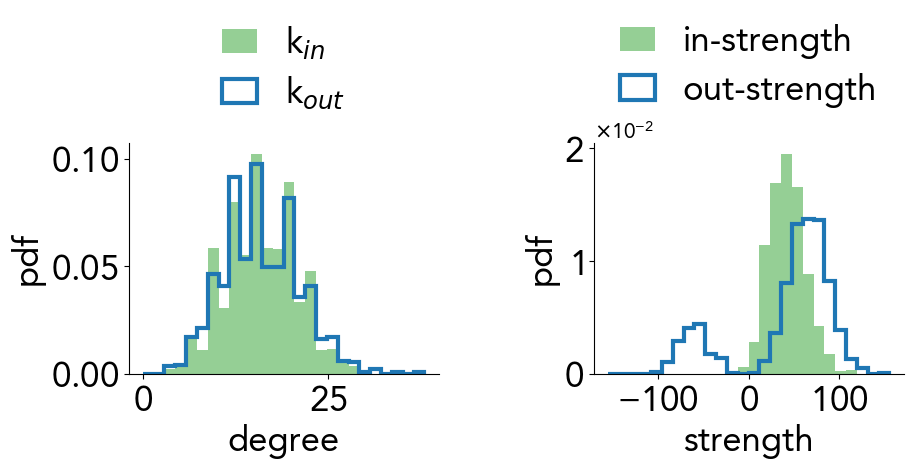

In [35]:
#----------------------------------------------------------------------------------------------------------------#
# how many links
N_links = np.sum(W!=0)
N_possible = len(W)*(len(W-1))
print('links fraction:\t',N_links/N_possible)

#---------------------------------------------------------------------------------------------------------------#
# in/out strength/degree
inDeg = np.sum(W!=0, axis=0); outDeg = np.sum(W!=0,axis=-1)
inStr = np.sum(W, axis=0);    outStr = np.sum(W,axis=-1)
print('in str < 0  N:\t',np.sum(inStr<0))

#----------------------------------------------------------------------------------------------------------------#


#----------------------------------------------------------------------------------------------------------------#
# PLOT: degree and strength

fig,axs=plt.subplots(1,2,figsize=(10,3))
#=== degree ===
ax=axs[0]
hmax=np.max([np.max(inDeg),np.max(outDeg)])
ax.hist(inDeg,  26, [-0.1,hmax], color='tab:green', density=True, alpha=0.5, label='k$_{in}$')
h = ax.hist(outDeg, 26, [-0.1,hmax], color='tab:blue', density=True, histtype='step', lw=3, label='k$_{out}$')
ax.set_xlabel('degree'); ax.set_ylabel('pdf')
pl.set_format(ax=ax, DIM = DIM, pwr_x_max=3, pwr_y_max=2, pwr_y_min=-2)
ax.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.65), labelspacing=0.4, handletextpad=0.8, handlelength = 1., frameon=False) 
#=== strengths ===
ax=axs[1]
hmax=np.max([np.max(inStr),np.max(outStr)])
ax.hist(inStr,  26, [-hmax,hmax], color='tab:green', density=True, alpha=0.5, label='in-strength')
ax.hist(outStr, 26, [-hmax,hmax], color='tab:blue', density=True, histtype='step', lw=3, label='out-strength')
ax.set_xlabel('strength'); ax.set_ylabel('pdf')
pl.set_format(ax=ax, DIM = DIM, pwr_x_max=3, pwr_y_max=2, pwr_y_min=-2)
ax.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.65), labelspacing=0.4, handletextpad=0.8, handlelength = 1., frameon=False) 
fig.subplots_adjust(wspace=0.5)
plt.savefig(path_imgs + 'connectivity_strength.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------------------#


## 4.1 Connectivity and distance

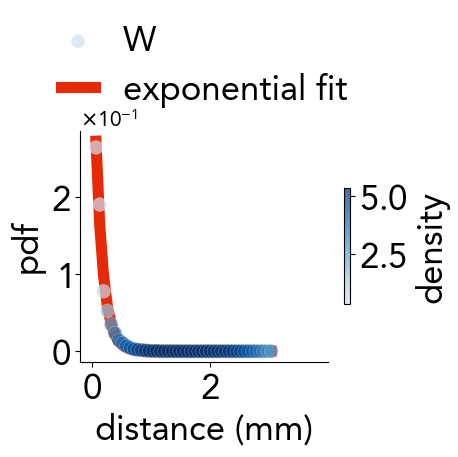

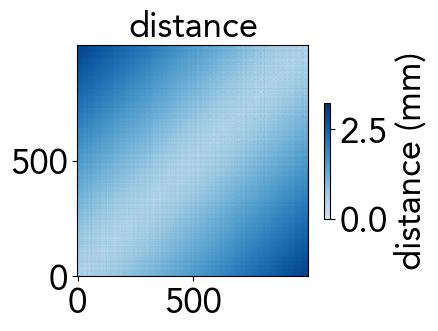

In [36]:
cmap=truncate_cmap(plt.get_cmap('Blues'), minval=0.2, maxval=1)

#---------------------------------------------------------------------------------------------------------------#
# compute probability of connection

mats = [W]; labs = 'W'; colz = 'tab:red'
P_conn,dist_conn,params_conn = pl.fit_measure(W, dist_mat, N_bins=50, bounds=(-np.inf,np.inf))
pl.plot_fit_meas(P_conn, dist_conn, params_conn, colz, labs, xmax=4, cmap=cmap, figsize=(4,3))

#------------------------------------------------------------------------------------------------------------#
# PLOT: probability of connection
fig,ax=plt.subplots(figsize=(4,3))
cmap=truncate_cmap(plt.get_cmap('Blues'), minval=0.2, maxval=1)
im = ax.imshow(dist_mat,cmap=cmap, vmin=0, vmax=np.max(np.abs(dist_mat.flatten())))
ax.invert_yaxis()
ax.set_title('distance')
cbar = fig.colorbar(im, ax=ax, shrink=0.5, label='distance (mm)')
plt.savefig(path_imgs + 'connectivity_connection_prob.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------#


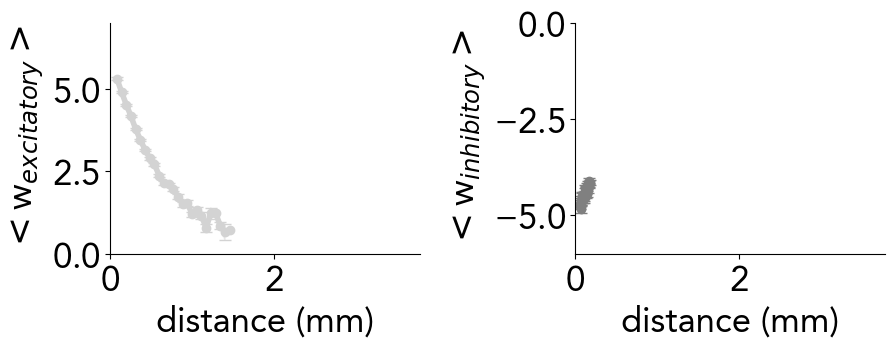

In [37]:
#---------------------------------------------------------------------------------------------------#
# PLOT: weights as a function of distance

fig,axs=plt.subplots(1,2,figsize=(10,3))
#=== excitatory ===
ax=axs[0]
y = W[net['ntypes']==True]; x = dist_mat[net['ntypes']==True]
pl.plot_binned_mean(y[y!=0],  x[y!=0],  xlabel='distance (mm)',
                    ylabel='w$_{excitatory}$', color='lightgrey',  N_bins=25, xmax=3.8,  ymin=0, ymax=7, ax=axs[0])
#=== inhibitory ===
ax=axs[1]
y = W[net['ntypes']==False]; x = dist_mat[net['ntypes']==False]
pl.plot_binned_mean(y[y!=0],  x[y!=0], xlabel='distance (mm)', 
                    ylabel='w$_{inhibitory}$', color='grey', N_bins=25,xmax=3.8, ymin=-6, ymax=0.01, ax=axs[1])
fig.subplots_adjust(wspace=0.5)
plt.savefig(path_imgs + 'connectivity_weights_distance.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------#


## 4.2 connectivity maps

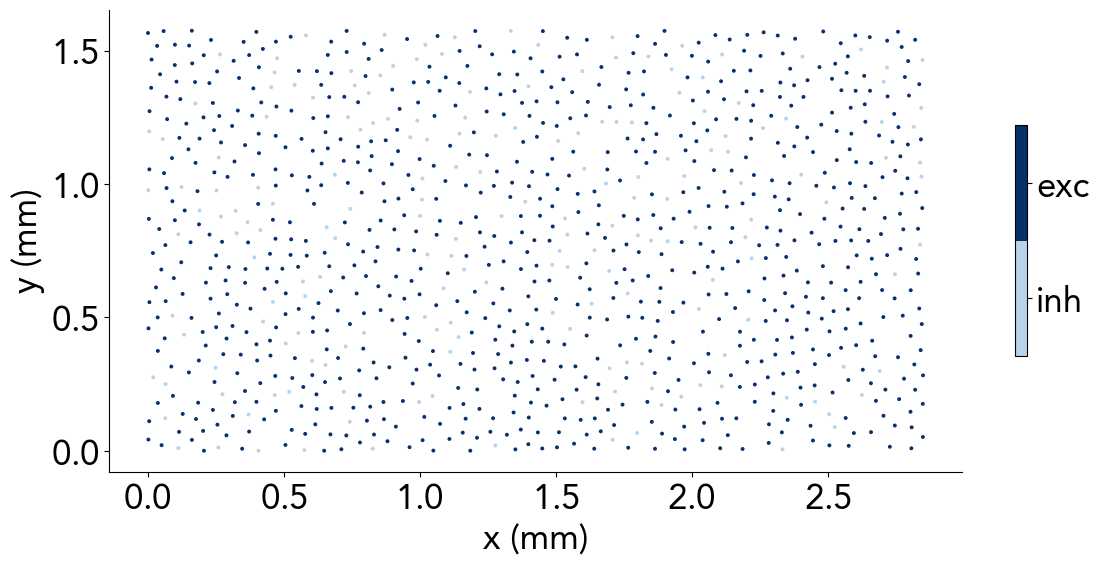

In [38]:
cmap2 = discrete_cmap('Blues', 2, minval=0.3, maxval=1)

# FULL MAP OF CHANNELS 
x = samples[:, 0]
y = samples[:, 1]

fig, ax = plt.subplots(figsize=(13.75, 6))
scatter = ax.scatter(x, y, s=8, marker='o', edgecolor='white', linewidths=0.01, c=net['ntypes'], cmap=cmap2, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM);    ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter,ax=ax,shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])

plt.savefig(path_imgs + 'map_neus.png', bbox_inches='tight')


/tmp/ipykernel_38862/330289116.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor=edgecolor, linewidths=0.1, c=cmap.colors[0], zorder=2)


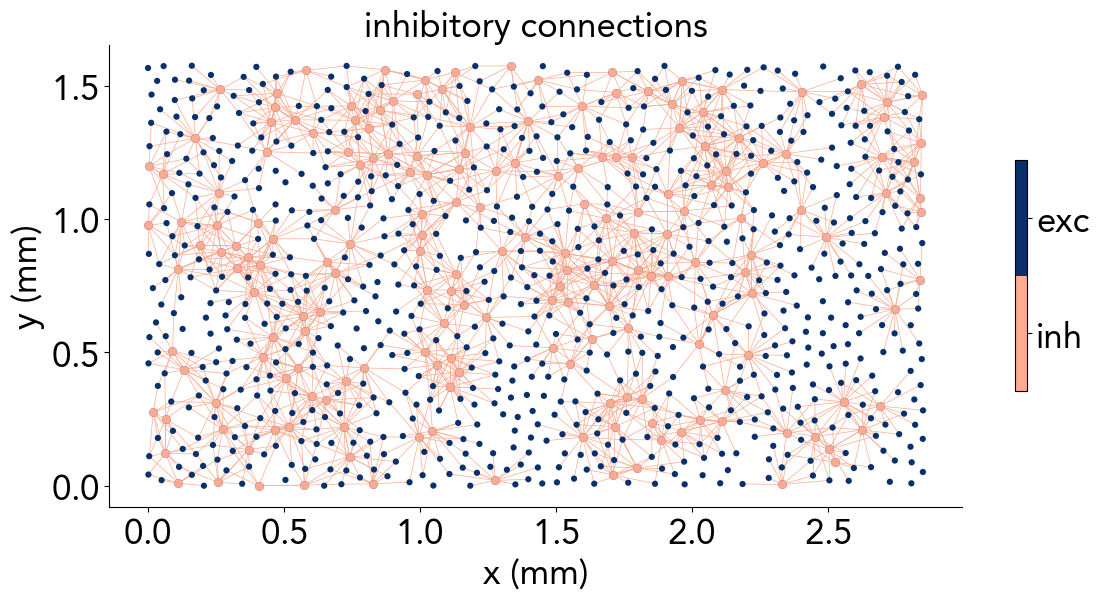

In [39]:
# (optional alt by sign, if you prefer sign-based split)
W_pos = np.where(W > 0.0, W, 0.0)   # "excitatory" by sign
W_neg = np.where(W < 0.0, W, 0.0)   # "inhibitory" by sign

#---------------------------------------------------------------------------------------------------#
# PLOT: neurons map - I connections

if modules=='2':
    edgecolor='white'
    dotsize=25
else:
    edgecolor='darkblue'
    dotsize=40
    
# FULL MAP OF CHANNELS + INH CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))
# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

# Plot neurons
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap.colors[0] = cmapR.colors[0]
scatter = ax.scatter(x, y, s=20, marker='o', edgecolor=edgecolor, linewidths=0.01, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor=edgecolor, linewidths=0.1, c=cmap.colors[0], zorder=2)

# neurond n. (NxN)
rows, cols = np.nonzero(W_neg)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[0], alpha=1, lw=.5, zorder=1)
    #ax.plot([x[j], x[i]], [y[j], y[i]], color='darkblue', alpha=0.8, lw=.15, zorder=1)
ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
ax.set_title('inhibitory connections')
plt.savefig(path_imgs + 'connectivity_neurons_map_Ilinks.png', bbox_inches='tight')
if show_plot==False:
    plt.close()

In [40]:
cmapR   = discrete_cmap('Reds', 2, minval=0.3, maxval=1)

cmap2   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmap2.colors[0] = cmapR.colors[0]

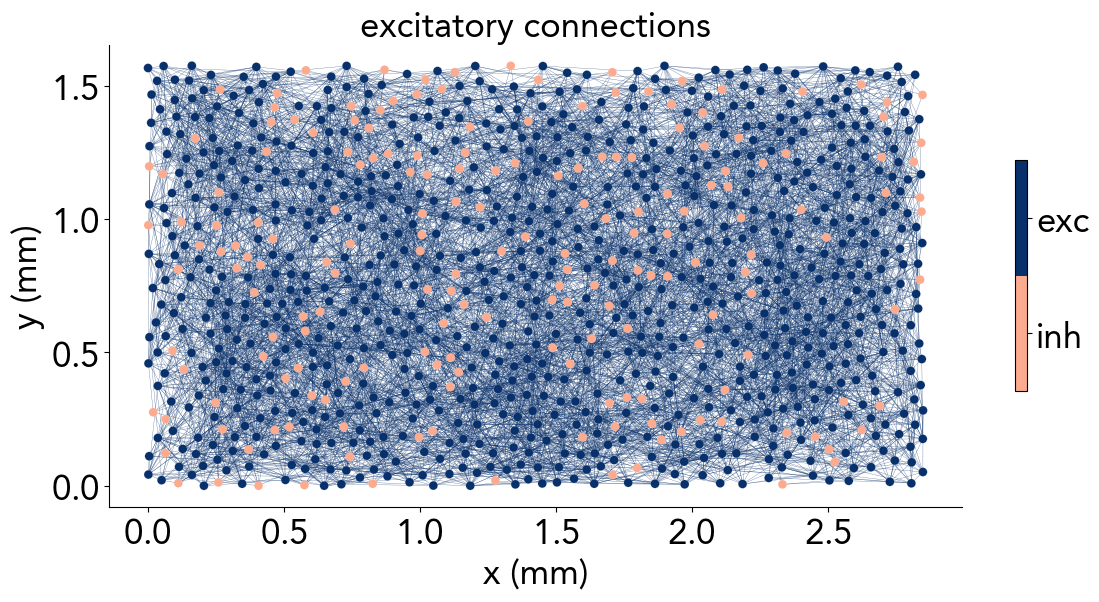

In [41]:
#---------------------------------------------------------------------------------------------------#
# PLOT: neurons map - E connections

if modules=='2':
    edgecolor='white'
    dotsize=20
else:
    edgecolor='white'
    dotsize=40

# FULL MAP OF CHANNELS + EXC CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))
# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]
# Plot neurons
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap.colors[0] = cmapR.colors[0]
scatter = ax.scatter(x, y, s=dotsize, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)

# existing connections (W ≠ 0)
rows, cols = np.nonzero(W_pos)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[1], alpha=0.8, lw=.2, zorder=0)
ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
ax.set_title('excitatory connections')
plt.savefig(path_imgs + 'connectivity_neurons_map_Elinks.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------#


/tmp/ipykernel_38862/4092823492.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
/tmp/ipykernel_38862/4092823492.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
/tmp/ipykernel_38862/4092823492.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case i

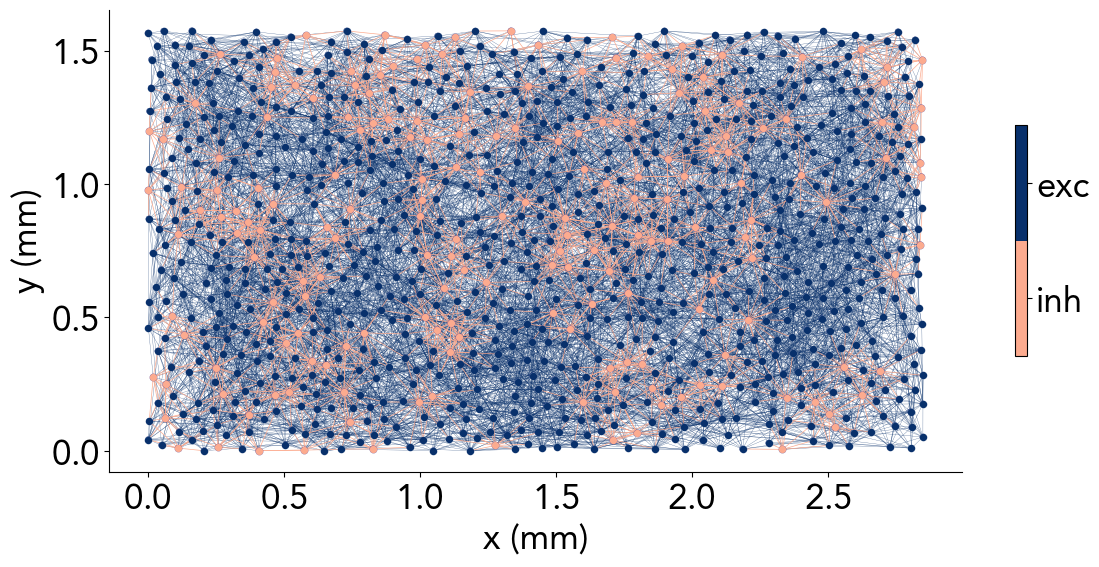

In [42]:
# FULL MAP OF CHANNELS + CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))

# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

if modules=='2':
    edgecolor='white'
    dotsize=20
else:
    edgecolor='darkblue'
    dotsize=30
    
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap.colors[0] = cmapR.colors[0]

# Plot neurons
scatter = ax.scatter(x, y, s=dotsize-10, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor='darkblue', linewidths=0.1, c=cmap.colors[0], cmap=cmap, zorder=3)
# neurond n. (NxN)
N = W.shape[0]

# existing connections (W ≠ 0)
'''rows, cols = np.nonzero(W)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)
'''
rows, cols = np.nonzero(W_pos)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[1], alpha=0.8, lw=.2, zorder=0)
rows, cols = np.nonzero(W_neg)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[0], alpha=1, lw=.5, zorder=1)

ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
plt.savefig(path_imgs + 'connectivity_neurons_map.png', bbox_inches='tight')


## 4.3 Connection Statistics

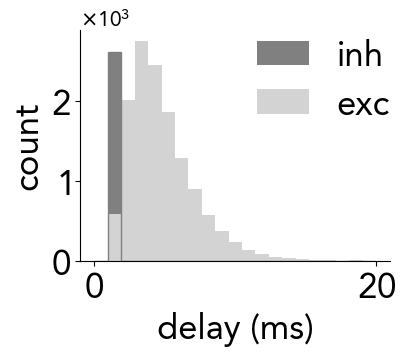

In [43]:
fig,ax = plt.subplots(figsize=(4,3))
dels = net['delays'][net['ntypes']==False]
h=plt.hist(dels[dels!=0],21,[0,20],color='grey', label='inh')
dels = net['delays'][net['ntypes']==True]
h=plt.hist(dels[dels!=0],21,[0,20],color='lightgrey', label='exc')
dels = net['delays'][net['ntypes']==False]
h=plt.hist(dels[dels!=0],21,[0,20],color='grey', histtype='step')

plt.xlabel('delay (ms)')
plt.ylabel('count')
pl.set_format(ax=ax, DIM= DIM, pwr_x_max=2, pwr_y_max=2)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), labelspacing=0.4, 
              handletextpad=0.8, handlelength = 1.5, frameon=False)
plt.savefig(path_imgs + 'delays_hist.png', bbox_inches='tight')

In [44]:
#---------------------------------------------------------------------------------------------------#
# CONNECTION STATISTICS

types = np.asarray(net['ntypes']).astype(bool)  # True = Excitatory (E), False = Inhibitory (I)
pos   = np.asarray(net['pos'])

# Distance matrix (mm)
try:
    D = np.asarray(net['dist_matrix'])
except KeyError:
    D = np.linalg.norm(pos[:,None,:] - pos[None,:,:], axis=2)
np.fill_diagonal(D, 0.0)

# Edges and type masks (rows = presyn, cols = postsyn)
E_pre  = types[:, None]
I_pre  = ~E_pre
E_post = types[None, :]
I_post = ~E_post
edge   = (W != 0.0)

# Short/Long range split
r_short  = 0.60  # mm (tune as you like)
is_short = (D <= r_short)
is_long  = ~is_short

# ---- Counts (TOTAL, not per-neuron) -----------------------------------------
stats = {
    "E->E_short": int(np.sum(edge & E_pre & E_post & is_short)),
    "E->E_long" : int(np.sum(edge & E_pre & E_post & is_long)),
    "E->I_short": int(np.sum(edge & E_pre & I_post & is_short)),
    "E->I_long" : int(np.sum(edge & E_pre & I_post & is_long)),
    "I->E_short": int(np.sum(edge & I_pre & E_post & is_short)),
    "I->E_long" : int(np.sum(edge & I_pre & E_post & is_long)),
    "I->I_short": int(np.sum(edge & I_pre & I_post & is_short)),
    "I->I_long" : int(np.sum(edge & I_pre & I_post & is_long)),
}
print(stats)

# ---- Extras (per-type quick summaries) --------------------------------------
# Out-degree (number of targets) split by range and type of postsyn
outdeg_EE_short = np.sum(edge & E_pre & E_post & is_short, axis=1)  # per-presyn neuron
outdeg_EI_short = np.sum(edge & E_pre & I_post & is_short, axis=1)
outdeg_IE_short = np.sum(edge & I_pre & E_post & is_short, axis=1)
outdeg_II_short = np.sum(edge & I_pre & I_post & is_short, axis=1)

# Mean out-degree by presyn type (short range)
print("mean_outdeg_E_short =",
      float(np.mean(outdeg_EE_short[types] + outdeg_EI_short[types])))
print("mean_outdeg_I_short =",
      float(np.mean(outdeg_IE_short[~types] + outdeg_II_short[~types])))

# Incoming inhibitory/excitatory degree per neuron (columns)
indeg_from_E = np.sum(edge & E_pre, axis=0)
indeg_from_I = np.sum(edge & I_pre, axis=0)
indeg_total  = indeg_from_E + indeg_from_I
frac_inhib_in = indeg_from_I / np.maximum(indeg_total, 1)

print("mean_frac_inhib_input(E postsyn) =", float(np.mean(frac_inhib_in[types])))
print("mean_frac_inhib_input(I postsyn) =", float(np.mean(frac_inhib_in[~types])))

# Average edge distance per category (mm)
def mean_dist(mask): 
    m = (mask & edge)
    return float(np.mean(D[m])) if np.any(m) else np.nan

print("avg_dist_E->E_short =", mean_dist(E_pre & E_post & is_short))
print("avg_dist_E->E_long  =", mean_dist(E_pre & E_post & is_long))
print("avg_dist_I->E_short =", mean_dist(I_pre & E_post & is_short))
print("avg_dist_I->E_long  =", mean_dist(I_pre & E_post & is_long))



# --- reusable masks and distance split ---
types = np.asarray(net['ntypes']).astype(bool)  # True=E, False=I
E_pre  = types[:, None]
I_pre  = ~E_pre
E_post = types[None, :]
I_post = ~E_post
edge   = (W != 0.0)

try:
    D = np.asarray(net['dist_matrix'])
except KeyError:
    P = np.asarray(net['pos'])
    D = np.linalg.norm(P[:,None,:] - P[None,:,:], axis=2)
np.fill_diagonal(D, 0.0)

r_short = 0.60  # mm  (edit if needed)
is_short = (D <= r_short)
is_long  = ~is_short

{'E->E_short': 10078, 'E->E_long': 786, 'E->I_short': 2308, 'E->I_long': 187, 'I->E_short': 2247, 'I->E_long': 0, 'I->I_short': 364, 'I->I_long': 0}
mean_outdeg_E_short = 15.291358024691357
mean_outdeg_I_short = 13.742105263157894
mean_frac_inhib_input(E postsyn) = 0.17194747151849005
mean_frac_inhib_input(I postsyn) = 0.12475278385946137
avg_dist_E->E_short = 0.24867267831574832
avg_dist_E->E_long  = 0.7554999725148597
avg_dist_I->E_short = 0.12418751817723221
avg_dist_I->E_long  = nan


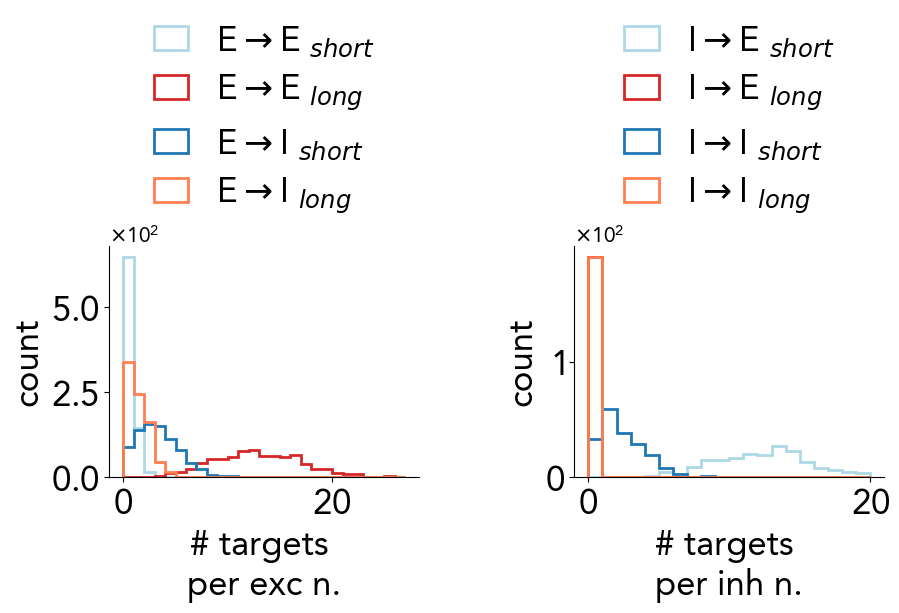

In [45]:

#---------------------------------------------------------------------------------------------------#
# PLOT: short - long connections

fig, axs = plt.subplots(1,2, figsize=(10,3))

#------
ax=axs[0]
# per-presyn counts among excitatory neurons only
selE = types

c_EE_short = np.sum(edge & E_pre & E_post & is_short, axis=1)[selE]
c_EE_long  = np.sum(edge & E_pre & E_post & is_long,  axis=1)[selE]
c_EI_short = np.sum(edge & E_pre & I_post & is_short, axis=1)[selE]
c_EI_long  = np.sum(edge & E_pre & I_post & is_long,  axis=1)[selE]

max_deg_E = int(max(1, c_EE_short.max(initial=0), c_EE_long.max(initial=0),
                       c_EI_short.max(initial=0), c_EI_long.max(initial=0)))
bins = np.arange(0, max_deg_E + 2)  # integer bins

'''ax.hist(c_EE_short, bins=bins, color='tab:red') #,   label=r'E$\rightarrow$E short')
ax.hist(c_EE_long,  bins=bins, color='coral') #,     label=r'E$\rightarrow$E long')
ax.hist(c_EI_short, bins=bins, color='tab:blue') #,  label=r'E$\rightarrow$I short')
ax.hist(c_EI_long,  bins=bins, color='lightblue') #, label=r'E$\rightarrow$I long')
'''
ax.hist(c_EI_long,  bins=bins, histtype='step', color='lightblue', lw=2, label=r'E$\rightarrow$E $_{short}$')
ax.hist(c_EE_short, bins=bins, histtype='step', color='tab:red',   lw=2, label=r'E$\rightarrow$E $_{long}$')
ax.hist(c_EI_short, bins=bins, histtype='step', color='tab:blue',  lw=2, label=r'E$\rightarrow$I $_{short}$')
ax.hist(c_EE_long,  bins=bins, histtype='step', color='coral',     lw=2, label=r'E$\rightarrow$I $_{long}$')

ax.set_xlabel('# targets \nper exc n.')
ax.set_ylabel('count')
ax.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.5, 2.1), labelspacing=0.4, 
              handletextpad=0.8, handlelength = 1., frameon=False)
pl.set_format(ax=ax, DIM=DIM, pwr_x_max=2)

#------
ax=axs[1]
# per-presyn counts among inhibitory neurons only
selI = ~types

c_IE_short = np.sum(edge & I_pre & E_post & is_short, axis=1)[selI]
c_IE_long  = np.sum(edge & I_pre & E_post & is_long,  axis=1)[selI]
c_II_short = np.sum(edge & I_pre & I_post & is_short, axis=1)[selI]
c_II_long  = np.sum(edge & I_pre & I_post & is_long,  axis=1)[selI]

max_deg_I = int(max(1, c_IE_short.max(initial=0), c_IE_long.max(initial=0),
                       c_II_short.max(initial=0), c_II_long.max(initial=0)))
bins = np.arange(0, max_deg_I + 2)  # integer bins

'''ax.hist(c_IE_short, bins=bins, color='tab:red')
ax.hist(c_IE_long,  bins=bins, color='coral')
ax.hist(c_II_short, bins=bins, color='tab:blue')
ax.hist(c_II_long,  bins=bins, color='lightblue')
'''

ax.hist(c_IE_short, bins=bins, histtype='step', color='lightblue', lw=2, label=r'I$\rightarrow$E $_{short}$')
ax.hist(c_II_long,  bins=bins, histtype='step', color='tab:red',   lw=2, label=r'I$\rightarrow$E $_{long}$')
ax.hist(c_II_short, bins=bins, histtype='step', color='tab:blue',  lw=2, label=r'I$\rightarrow$I $_{short}$')
ax.hist(c_IE_long,  bins=bins, histtype='step', color='coral',     lw=2, label=r'I$\rightarrow$I $_{long}$')

ax.set_xlabel('# targets \nper inh n.')
ax.set_ylabel('count')
ax.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.5, 2.10), labelspacing=0.4, 
              handletextpad=0.8, handlelength = 1., frameon=False) 
pl.set_format(ax=ax, DIM=DIM, pwr_x_max=2)

fig.subplots_adjust(wspace=0.5)

plt.savefig(path_imgs + 'connectivity_short_long_connections.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------#



In [46]:
path_data

'/data/tentori/github/in-silico_snn/Data_samples_2/Generated_network/network1000_1mod_EDR_II/Data/'